# Tutorial 3 · Eigen, SVD & PCA — Part B

**~40 minutes · after the worksheet**

Use repeated multiplication to find a dominant eigenvector, then compress data with SVD and PCA.

Work in pairs. Before each code cell, write down the qualitative result you expect. The notebook is designed to run top-to-bottom in a fresh kernel.


## 1 · Power iteration


In [1]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[3., 1.], [1., 3.]])
x = np.array([1., 0.])
for k in range(8):
    x = A @ x
    x /= np.linalg.norm(x)
    print(k + 1, x)


1 [0.9486833  0.31622777]
2 [0.85749293 0.51449576]
3 [0.78935222 0.61394061]
4 [0.74983786 0.66162164]
5 [0.72884807 0.68467546]
6 [0.71806768 0.69597329]
7 [0.71260931 0.7015611 ]
8 [0.7098635  0.70433927]


## 2 · Low-rank image reconstruction

The synthetic image keeps the experiment self-contained.


first ten singular values: [26.384  3.812  0.     0.     0.     0.     0.     0.     0.     0.   ]


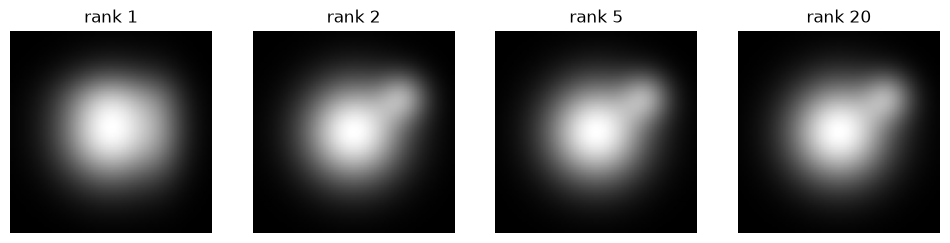

In [2]:
u = np.linspace(-2, 2, 80)
X, Y = np.meshgrid(u, u)
image = np.exp(-(X**2 + Y**2)) + .45*np.exp(-((X-1)**2 + (Y+.7)**2)/.25)
U, s, Vt = np.linalg.svd(image, full_matrices=False)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, rank in zip(axes, [1, 2, 5, 20]):
    approx = (U[:, :rank] * s[:rank]) @ Vt[:rank]
    ax.imshow(approx, cmap="gray"); ax.set_title(f"rank {rank}"); ax.axis("off")
print("first ten singular values:", np.round(s[:10], 3))


## 3 · PCA from the SVD of centred data


principal directions:
 [[-0.83117112 -0.5560167 ]
 [-0.5560167   0.83117112]]
explained fractions: [0.99088402 0.00911598]


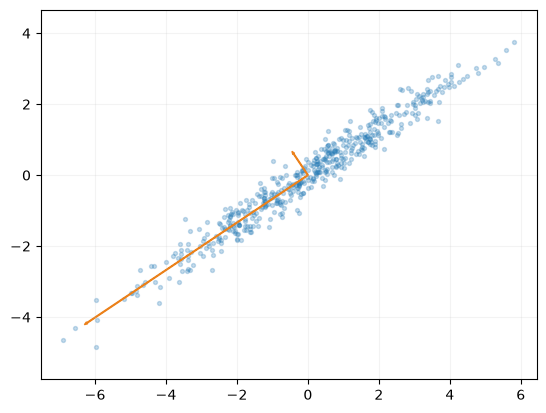

In [3]:
rng = np.random.default_rng(3)
Z = rng.normal(size=(500, 2)) @ np.array([[2.2, .3], [1.4, .5]]).T + [3, -2]
Zc = Z - Z.mean(axis=0)
_, s, Vt = np.linalg.svd(Zc, full_matrices=False)
print("principal directions:\n", Vt)
print("explained fractions:", s**2 / np.sum(s**2))
plt.scatter(*Zc.T, s=8, alpha=.25)
for scale, direction in zip(s[:2] / 8, Vt):
    plt.arrow(0, 0, *(scale * direction), width=.02, color="#EB811B")
plt.axis("equal"); plt.grid(alpha=.15);


## Closing check

Write three sentences: one numerical result you verified, one geometric/probabilistic interpretation, and one failure mode you would now test in a larger implementation.
